<a href="https://colab.research.google.com/github/JieChen8480/4501-Project/blob/main/OM_PhD_Upgraded_Regime_Uncertainty_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Regime-Dependent Prediction under Financial Market Uncertainty**

### From stock-price prediction to uncertainty-aware predictive decision-making

This upgraded version reframes the original project as an applied research project on **how model reliability changes across market regimes**. The goal is not simply to maximize directional prediction accuracy, but to evaluate whether predictive models remain stable under different uncertainty conditions.

**Research framing for PhD applications:** this project demonstrates experimental design, robustness testing, model comparison, regime-specific evaluation, and decision-making under uncertainty.

## **Research Upgrade: Why this version is stronger**

The original project studied machine learning techniques for stock-price prediction and regime classification. This upgraded version adds five research-grade components:

1. **LSTM volatility proxy** — uses sequential return information to construct a forward-looking uncertainty signal.
2. **Regime-specific performance comparison** — tests whether models work equally well across low-, medium-, and high-volatility regimes.
3. **Overfitting detection** — compares in-sample and out-of-sample performance gaps across models.
4. **Random-walk and naive benchmarks** — checks whether ML models beat simple financial-market baselines.
5. **Rolling-window validation** — evaluates model stability over time using repeated time-series splits.

This shifts the project from a standard ML prediction exercise toward a research-style question:

> **Do machine learning models produce reliable directional predictions when the underlying market regime changes?**

For an OM / operations research PhD application, this framing connects naturally to **forecasting under uncertainty, robustness, data-driven decision-making, and model reliability under non-stationarity**.

## **Packages Import**


In [1]:
import datetime
import glob
import math
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import warnings
import xlrd

from scipy import stats
from scipy import linalg
from scipy.stats import multivariate_normal
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
from google.colab import files

## **Utility functions**

In [12]:
def sample_time_between(data, start, end):
    sample = [start <= i.strftime("%H:%M") <= end for i in data.index]
    sample_index = data.index[sample]
    return data.loc[sample_index]


def sample_time_not_between(data, start, end):
    sample = [start > i.strftime("%H:%M") or i.strftime("%H:%M") >= end for i in data.index]
    sample_index = data.index[sample]
    return data.loc[sample_index]


def extract_factors_5min(data_5min, back_period=36):
    # Data is so sparse on a 1-min basis
    # Group 1-minute level data into 5-minute basis
    data = data_5min.copy()
    vol_5m = data['Volume']
    close_5m = data['Close']
    open_5m = data['Open']
    high_5m = data['High']
    low_5m = data['Low']

    # correlation coefficient between price and volume
    # look back last 5 hrs when back_period=36
    data['cor_vol_price'] = vol_5m.rolling(back_period).corr(close_5m)

    # return sum after breaking certain level volume
    vol_standard = vol_5m.rolling(72).mean() + 2.5 * vol_5m.rolling(144).std()
    ret = close_5m.div(close_5m.shift(1)) - 1
    data['ret_break_vol'] = ret[vol_5m > vol_standard].reindex_like(ret).replace(np.nan, 0.0)
    # range
    data['range_5m'] = ((high_5m - low_5m) / close_5m)
    # average line
    data['mv_3hrs_5'] = close_5m.rolling(36).mean()
    data['crossing_mv'] = (close_5m>data['mv_3hrs_5']).astype(int).rolling(72).sum()
    # skewness kurtosis std
    data['r_std_12hrs_5'] = ret.rolling(144).std()
    data['r_skew_12hrs_5'] = ret.rolling(144).skew()
    data['r_kurt_12hrs_5'] = ret.rolling(144).kurt()
    data['r_std_3hrs_5'] = ret.rolling(36).std()
    data['r_skew_3hrs_5'] = ret.rolling(36).skew()
    data['r_kurt_3hrs_5'] = ret.rolling(36).kurt()
    data['ret'] = ret
    return data

def prepare_other_futures(df,name):
    # in order to process other futures data to add them as predictors
    # add 10Year Treasury, Crude Oil and VIX which also have the same trading time with sp500 futures
    # And we believe they can provide information to predict sp500 futures
    data = df.copy()
    data['Date'] = data['Date'].apply(lambda x: xlrd.xldate_as_datetime(x, 0))
    data['DateTimeExchange'] = data['DateTimeExchange'].apply(lambda x: xlrd.xldate_as_datetime(x, 0))
    data['DateTimeLocal'] = data['DateTimeLocal'].apply(lambda x: xlrd.xldate_as_datetime(x, 0))
    data = data.drop(columns=['Date', 'DateTimeExchange', 'Time2', 'Hour', 'Min'])
    data = data.set_index('DateTimeLocal')
    data1 = data.filter(like='1')
    data1.columns = ['Symbol', 'Name', 'Price', 'CumVolume']
    data1 = sample_time_not_between(data1, '17:00', '18:00')
    data1['Volume'] = data1['CumVolume'].diff()
    # reset its CumVolume at certain time.
    data1.dropna(inplace=True)
    data1['Volume'] = data1['Volume'].replace(0.0, np.nan)
    data1['Volume'] = np.where(data1['Volume'] < 0, 0, data1['Volume'])
    data1.dropna(inplace=True)
    # Get the OHLC Vwap on a 5-minute basis.
    Volume_1 = data1['Volume'].resample('5min').sum().dropna()
    Close_1 = data1['Price'].resample('5min').last().dropna().rename('Close')
    Open_1 = data1['Price'].resample('5min').first().dropna().rename('Open')
    High_1 = data1['Price'].resample('5min').max().dropna().rename('High')
    Low_1 = data1['Price'].resample('5min').min().dropna().rename('Low')
    Vp = (data1['Price'] * data1['Volume']).resample('5min').sum()
    Vwap_1 = pd.DataFrame(Vp.div((Volume_1.replace(0, 1))), columns=['Vwap'])
    ret = Close_1.div(Close_1.shift(1))-1
    ret.rename(name+'_ret',inplace = True)
    Close_1.rename(name+'_close',inplace=True)
    return ret,Close_1

def sharpe(ret):
    nonneg_ret = ret.iloc[ret.to_numpy().nonzero()]
    sharpe = np.mean(nonneg_ret)/np.std(nonneg_ret)
    return sharpe

def backtest(signal_in_sample,signal_out_sample,title,mxd = False,display=False):
    # Evaluate the performance of classifiers by using predictions as trading signal
    # Use long only strategy (Hold long position when prediction is positive)
    split_date = signal_out_sample.index[0]
    signal_total = pd.concat([signal_in_sample,signal_out_sample])
    new_ret = pd.merge(signal_total,feature_futures_5min[['ret']],left_index=True,right_index=True)
    new_ret['signal'] = new_ret['signal'].shift(1)
    new_ret['returns'] = new_ret['signal']*new_ret['ret']
    new_ret['returns'] = new_ret['returns'].fillna(0)
    cumret = (new_ret['returns']+1).cumprod()-1
    returns_in = new_ret['returns'][:split_date]
    returns_out = new_ret['returns'][split_date:]
    cum_return_in = cumret[:split_date]
    cum_return_out = cumret[split_date:]
    plt.figure(figsize=(16,9))
    plt.plot(cum_return_in)
    plt.plot(cum_return_out)
    max_draw_down_in = np.min(cum_return_in-cum_return_in.cummax())
    max_draw_down_out = np.min(cum_return_out-cum_return_out.cummax())
    down_in = np.argmin(cum_return_in-cum_return_in.cummax())
    down_out = np.argmin(cum_return_out-cum_return_out.cummax())
    flag1 = cum_return_in.index[down_in]
    up_limit = max((new_ret['returns']+1).cumprod()-1)
    down_limit = min((new_ret['returns']+1).cumprod()-1)
    flag2 = cum_return_out.index[down_out]
    if mxd:
      plt.vlines(flag1,down_limit,up_limit,colors= 'r',linestyles='dashed',label='Max_drawdown for train')
      plt.vlines(flag2,down_limit,up_limit,colors= 'y',linestyles='dashed',label='Max_drawdown for test')
      plt.legend()
    # Calculate Sharpe Ratio using non-zero returns
    sharp_in_sample = sharpe(returns_in)
    sharp_out_sample = sharpe(returns_out)
    plt.title(title)
    if display:
      print('Max drawdown in sample',max_draw_down_in)
      print('Max drawdown out sample',max_draw_down_out)
      print('Sharpe in sample:',sharp_in_sample)
      print('Sharpe out sample:',sharp_out_sample)


## **Data Preprocessing**

In [3]:
# set working directory
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/Cost2 project/Cost 2/Data'

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1AZqLDpNIpIqtEgayXTMxDEkvjHIyQf_i/Cost 2/Data


###Load E-Mini S&P 500 Futures Data

In [4]:
# read the SP500 futures data from csv file
data = pd.read_csv("Mini.csv")
data.head()

,Date,DateTimeExchange,DateTimeLocal,Time2,Hour,Min,Symbol1,Symbol1_name,Price1,CumVolume1,Symbol2,Symbol2_name,Price2,CumVolume2,DistanceSwitch
0,44377,44376.958333,44377.000000,44377.000000,0,0,96,ESU21,4287.50,24436,97,ESZ21,4275.5,5102,9999
1,44377,44376.959028,44377.000694,44377.000694,0,1,96,ESU21,4287.25,24509,97,ESZ21,4275.5,5102,9999
2,44377,44376.959722,44377.001389,44377.001389,0,2,96,ESU21,4287.00,24567,97,ESZ21,4275.5,5102,9999
3,44377,44376.960417,44377.002083,44377.002083,0,3,96,ESU21,4287.00,24651,97,ESZ21,4275.5,5102,9999
4,44377,44376.961111,44377.002778,44377.002778,0,4,96,ESU21,4287.25,24695,97,ESZ21,4275.5,5102,9999


In [5]:
# format the 'Date', 'DateTimeExchange', 'DateTimeLocal' columns
# covert excel serial date into datetime object
data['Date'] = data['Date'].apply(lambda x: xlrd.xldate_as_datetime(x, 0))
data['DateTimeExchange'] = data['DateTimeExchange'].apply(lambda x: xlrd.xldate_as_datetime(x, 0))
data['DateTimeLocal'] = data['DateTimeLocal'].apply(lambda x: xlrd.xldate_as_datetime(x, 0))

In [6]:
# drop duplicate columns and split into 2 parts based on 'Symbol'
# 'Symbol1' and 'Symbol2' are the front and the second contract traded in the futures market
data = data.drop(columns=['Time2', 'Date', 'DateTimeExchange', 'Hour', 'Min'])
data = data.set_index('DateTimeLocal')
data1 = data.filter(like='1')
data2 = data.filter(like='2')
data2 = data2[data2['Symbol2'] != -1]
data1.columns = ['Symbol', 'Name', 'Price', 'CumVolume']
data2.columns = ['Symbol', 'Name', 'Price', 'CumVolume']
data_s1 = {}
data_s2 = {}
# print(data1.head())
# print(data2.head())

In [13]:
# Keep front contract only ('Symbol1')
# Drop the data during non trading hours and holidays
data1 = sample_time_not_between(data1, '17:00', '18:00')
sample = ['21-12-23 18:00' > i.strftime("%y-%m-%d %H:%M") or \
          i.strftime("%y-%m-%d %H:%M") >= '21-12-26 18:00' for i in data1.index]
sample_index = data1.index[sample]
data1 = data1.loc[sample_index]
data1['Volume'] = data1['CumVolume'].diff()
data1.dropna(inplace=True)

# Drop invalid observations
data1['Volume'] = data1['Volume'].replace(0.0, np.nan)
data1['Volume'] = np.where(data1['Volume'] < 0, 0, data1['Volume'])
data1.dropna(inplace=True)

# Group 1-minute level data into 5-minute basis
# Get the OHLC and VWAP for 5-minute data
Volume_1 = data1['Volume'].resample('5min').sum().dropna()
Open_1 = data1['Price'].resample('5min').first().dropna().rename('Open')
High_1 = data1['Price'].resample('5min').max().dropna().rename('High')
Low_1 = data1['Price'].resample('5min').min().dropna().rename('Low')
Close_1 = data1['Price'].resample('5min').last().dropna().rename('Close')
Vp = (data1['Price'] * data1['Volume']).resample('5min').sum()
Vwap_1 = pd.DataFrame(Vp.div((Volume_1.replace(0, 1))), columns=['Vwap'])
data_1_5min = pd.concat([Volume_1, Close_1, Open_1, High_1, Low_1, Vwap_1], axis=1).dropna()

# Extract features from 5-minute data using helper functions
feature_futures_5min = extract_factors_5min(data_1_5min).dropna()

In [14]:
feature_futures_5min.head()

,Volume,Close,Open,High,Low,Vwap,cor_vol_price,ret_break_vol,range_5m,mv_3hrs_5,crossing_mv,r_std_12hrs_5,r_skew_12hrs_5,r_kurt_12hrs_5,r_std_3hrs_5,r_skew_3hrs_5,r_kurt_3hrs_5,ret
DateTimeLocal,,,,,,,,,,,,,,,,,,
2021-06-30 12:05:00,3983.0,4284.50,4285.25,4285.25,4284.50,4284.992405,0.081242,0.0,0.000175,4283.645833,57.0,0.000292,-0.112742,1.582625,0.000352,0.346571,-0.366429,0.000058
2021-06-30 12:10:00,3397.0,4285.25,4284.75,4285.50,4284.75,4285.114513,-0.015903,0.0,0.000175,4283.916667,58.0,0.000292,-0.123311,1.561372,0.000348,0.271607,-0.302957,0.000175
2021-06-30 12:15:00,5313.0,4286.25,4285.75,4286.25,4285.50,4285.806889,-0.147628,0.0,0.000175,4284.208333,59.0,0.000293,-0.135570,1.525572,0.000349,0.228183,-0.355703,0.000233
2021-06-30 12:20:00,6247.0,4284.75,4286.00,4286.00,4284.75,4285.312310,-0.337882,0.0,0.000292,4284.472222,59.0,0.000294,-0.120235,1.446536,0.000354,0.230084,-0.457833,-0.000350
2021-06-30 12:25:00,6269.0,4283.50,4284.00,4284.00,4283.50,4283.694210,-0.427466,0.0,0.000117,4284.625000,58.0,0.000295,-0.116296,1.412274,0.000345,0.311993,-0.299104,-0.000292


In [15]:
feature_futures_5min.describe()

,Volume,Close,Open,High,Low,Vwap,cor_vol_price,ret_break_vol,range_5m,mv_3hrs_5,crossing_mv,r_std_12hrs_5,r_skew_12hrs_5,r_kurt_12hrs_5,r_std_3hrs_5,r_skew_3hrs_5,r_kurt_3hrs_5,ret
count,70066.000000,70066.000000,70066.000000,70066.000000,70066.00000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000,70066.000000
mean,5456.499957,4402.848964,4402.861798,4404.040462,4401.66229,4402.787619,-0.063412,-0.000004,0.000550,4402.943776,38.135472,0.000634,-0.052502,4.362093,0.000593,-0.014058,1.507125,-0.000001
std,9476.624261,232.523401,232.517201,232.206140,232.83887,233.114408,0.385545,0.000378,0.000604,232.267241,17.655223,0.000389,0.995109,6.393078,0.000449,0.836131,2.743255,0.000744
min,0.000000,3641.250000,3643.250000,3646.500000,3641.25000,0.000000,-0.964653,-0.013245,0.000000,3662.659722,0.000000,0.000104,-9.062807,-0.515932,0.000061,-5.500217,-1.440597,-0.022429
25%,611.000000,4311.812500,4311.750000,4313.250000,4310.50000,4311.747464,-0.356824,0.000000,0.000176,4312.279514,25.000000,0.000338,-0.447263,1.464814,0.000277,-0.455129,-0.011239,-0.000233
50%,1443.500000,4431.750000,4431.500000,4432.750000,4430.25000,4431.614274,-0.082925,0.000000,0.000361,4431.590278,39.000000,0.000532,-0.024630,2.709494,0.000461,-0.021357,0.749918,0.000000
75%,6542.000000,4557.000000,4557.000000,4558.250000,4555.75000,4557.068252,0.224420,0.000000,0.000688,4556.866319,52.000000,0.000844,0.401561,4.797697,0.000770,0.414319,1.995138,0.000262
max,250340.000000,4807.250000,4806.750000,4807.250000,4806.50000,4806.729545,0.945938,0.012447,0.027380,4802.541667,72.000000,0.002293,5.467098,99.233850,0.004000,4.737042,32.032283,0.012447


In [16]:
# data1[data1.index>='2022-02-10 08:29'].tail(10)

### Simulate a random walk time series

In [17]:
# Using Milstein

def random_walk(sig,mu,n_period,s0):
  s = s0
  # np.random.seed(0)
  z = np.random.randn(n_period)
  dt = 1/n_period
  path = [s]
  for i in range(n_period):
      # Milstein
      s = s + mu*s*dt + sig*s*np.sqrt(dt)*z[i] + 0.5*sig*sig*s*dt*(z[i]**2 - 1)
      path.append(s)
  return path
n = len(feature_futures_5min)-1
rand_walk = pd.DataFrame(index=feature_futures_5min.index)
sig = .15
mu = 0
s0 = feature_futures_5min.iloc[0]['Close']
rand_walk['Price'] = random_walk(sig,mu,n,s0)
rand_walk

,Price
DateTimeLocal,
2021-06-30 12:05:00,4284.500000
2021-06-30 12:10:00,4282.106963
2021-06-30 12:15:00,4273.974012
2021-06-30 12:20:00,4272.191131
2021-06-30 12:25:00,4271.777872
...,...
2022-06-24 16:35:00,4921.686048
2022-06-24 16:40:00,4918.068302
2022-06-24 16:45:00,4912.386672


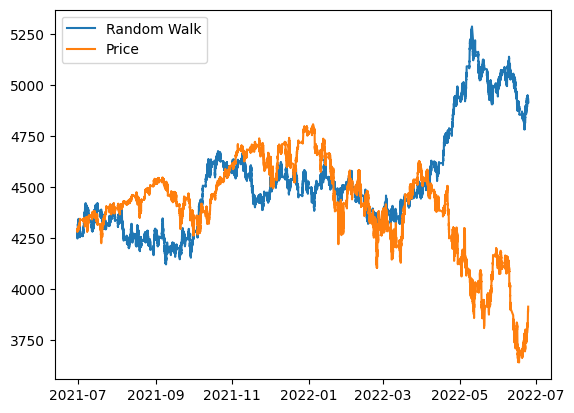

In [18]:
plt.plot(rand_walk,label='Random Walk')
plt.plot(feature_futures_5min.Close,label='Price')
plt.legend()
plt.show()
#assessing how closely the random walk simulation matches the actual price movements of the asset.
#It can provide insights into the effectiveness of the simulation model
# and its suitability for financial analysis or predictive modeling.

###Adding futures data as features

In [ ]:
def read_futures_data():
    """
    This function reads the data of 18 futures and returns
    a dictionary containing the data of each future.

    Returns:
    dict: A dictionary containing the data of each future.
    """
    # Get the current working directory
    path = os.getcwd()
    # print(path)
    # print(os.path.join(path, "*.csv"))
    # Find all the csv files in the data folder
    csv_files = glob.glob(os.path.join(path, "*.csv"))
    # print(csv_files)
    # Read all the futures data and save each dataframe under its name
    futures = dict()
    rets = dict()
    close = dict()
    for f in csv_files:
        name = f.split('/')[-1].split('.')[0]
        futures[name] = pd.read_csv(f)
        rets[name], close[name] = prepare_other_futures(futures[name], name)
    return futures, rets, close

In [20]:
futures, rets, close = read_futures_data()

KeyboardInterrupt: 

In [ ]:
name = input("Enter names of Future: ")

In [ ]:
def preprocess_fin(names, feature_futures_5min):
    """
    Preprocesses financial data for futures trading by merging dataframes,
    dropping invalid data, and downloading prepared data for future use.

    Args:
    names: list of string - the names of the financial data
    feature_futures_5min: pandas dataframe - the financial data

    Returns:
    feature_futures_5min: pandas dataframe - the preprocessed financial data
    """
    # merge dataframes
    for name in names.split():
        name = name.strip()

        feature_futures_5min = pd.merge(feature_futures_5min,rets[name],left_index=True,right_index=True,how='left')

    # select data with valid time
    sample = [i.strftime("%H:%M") != '18:00' for i in feature_futures_5min.index]
    sample_index = feature_futures_5min.index[sample]
    feature_futures_5min=feature_futures_5min.loc[sample_index]

    # drop invalid data
    feature_futures_5min.dropna(inplace=True)

    # download prepared data for future use
    feature_futures_5min.to_csv('/content/drive/My Drive/feature_futures_5min.csv', encoding = 'utf-8-sig')

    return feature_futures_5min


In [ ]:
feature_futures_5min = preprocess_fin(name, feature_futures_5min)
feature_futures_5min

In [ ]:
feature_futures_5min.columns

## **Data Visualization**


###Heatmap

In [ ]:
def count_nonzero_returns(target):
    """
    This function counts the number of periods of positive and negative returns.

    Args:
      target (DataFrame): DataFrame containing the 'ret' column representing returns.

    Returns:
      DataFrame: Counts of positive and negative returns.

    """
    target = (target['ret']>0).astype(int)
    return target.value_counts()

In [ ]:
count_nonzero_returns(feature_futures_5min)

In [ ]:
def visualize_correlation_heatmap(df):
    """
    Visualize the correlations between all features in a DataFrame using a heatmap.

    Args:
        df (DataFrame): Input DataFrame containing the features.

    Returns:
        None
    """
    # Calculate the correlation matrix
    corr_matrix = df.corr()

    # Create a heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix)

    plt.title('Correlation Heatmap')
    plt.show()

In [ ]:
visualize_correlation_heatmap(feature_futures_5min)

### Time Series Plots

In [ ]:
import matplotlib.pyplot as plt

def plot_feature_futures_5min(feature_futures_5min, name):
    """
    Plots various features of 5-minute futures data.

    Parameters:
    - feature_futures_5min (pandas.DataFrame): a DataFrame containing the 5-minute futures data.
    - name (str): a Python string containing the name(s) of the futures used as features

    Returns: None
    """

    # Plot cumulative returns of VIX, crude oil, gold, and mini futures
    for n in name.split():
      plt.plot((feature_futures_5min[n.replace(' ', '') + '_ret']+1).cumprod()-1,label=n)

    plt.plot((feature_futures_5min['ret']+1).cumprod()-1,label='Mini')
    plt.legend()
    plt.title('Cumulative Returns')
    plt.ylabel('Return')
    plt.xlabel('Time')
    plt.show()

    # Plot 5-minute price range of SP500 futures
    feature_futures_5min['range_5m'].plot(title='5-min Price Range of E-Mini').set_ylabel('Price Range')
    plt.show()

    # Plot 5-minute correlation of volume and price of SP500 futures
    feature_futures_5min['cor_vol_price'].plot(title='5-min Correlation between Volume and Price of E-Mini').set_ylabel('Correlation')
    plt.show()

    # Plot 5-minute volume of SP500 futures
    volume_5min = feature_futures_5min['Volume']
    volume_5min.plot(title='5-minute Volume of E-Mini').set_ylabel('Volume')
    plt.show()

    # Plot 5-minute returns of SP500
    return_5min = feature_futures_5min['ret']
    return_5min.plot(title='5-min Return of E-Mini Futures').set_ylabel('Return')
    plt.show()

    # Plot 5-minute returns of Crude Oil, Gold, and/or VIX features
    for n in name.split():
      return_5min = feature_futures_5min[n.replace(' ', '') + '_ret']
      return_5min.plot(title='5-min Return of' + n + 'Futures').set_ylabel('Return')
      plt.show()

    # Plot standard deviation of 5-minute returns of SP500 futures in the past 3 hours
    feature_futures_5min['r_std_3hrs_5'].plot(title='Std of 5-min Return of E-Mini futures in 3 hours').set_ylabel('Return')
    plt.show()

    # Plot 5-minute returns of SP500 futures when it breaks certain volume
    feature_futures_5min['ret_break_vol'].plot(title='5-min Return of SP500 Futures when Break Certain Volume').set_ylabel('Return')
    plt.show()

In [ ]:
plot_feature_futures_5min(feature_futures_5min, name)

### Histogram Plots


In [ ]:
def plot_histograms(feature_futures_5min, name):
    """
    Plots histograms of returns for S&P500 Mini, and selected feature

    Parameters:
    - feature_futures_5min (pandas.DataFrame): a DataFrame containing the 5-minute futures data.
    - name (str): a Python string containing the name(s) of the futures used as features

    Returns: None
    """

    # Plot the histogram of returns for each asset
    assets = ['SP500']
    returns = ['ret']

    for n in name.split():
      assets.append(n)
      returns.append(n.replace(' ', '') + '_ret')

    for i, asset in enumerate(assets):
        plt.hist(feature_futures_5min[returns[i]], bins=50)
        plt.title(f'5-min Returns of {asset}')
        plt.xlabel('Return')
        plt.ylabel('Occurance')
        plt.show()

    # Plot the four histograms in one for better comparison
    for n in name.split():
      plt.hist([feature_futures_5min['ret'], feature_futures_5min[n.replace(' ', '') + '_ret']],
             bins=50, label=['SP500', n])

    plt.legend(loc='upper right')
    plt.title('5min Returns')
    plt.xlabel('Return')
    plt.ylabel('Occurance')
    plt.show()

    # Zoom in for a closer look
    for n in name.split():
      plt.hist([feature_futures_5min['ret'], feature_futures_5min[n.replace(' ', '') + '_ret']],
             bins=np.linspace(-0.02, 0.02, 10), label=['SP500', n])

    plt.legend(loc='upper right')
    plt.title('5min Returns')
    plt.xlabel('Return')
    plt.ylabel('Occurance')
    plt.show()


# Example usage:
"""
# Load data
df = pd.read_csv('data.csv')
# Call function
plot_histograms(df, name)

# Unit test class
class TestPlotHistograms(unittest.TestCase):
    def setUp(self):
        self.df = pd.DataFrame({'ret': [0.001, 0.002, -0.001, -0.002],
                                'VIX_ret': [0.003, 0.002, -0.004, -0.001],
                                'Gold_ret': [0.002, 0.001, -0.002, -0.003],
                                'CrudeOil_ret': [-0.001, 0.003, -0.003, 0.001]})

    def test_plot_histograms(self):
        # Test that the function runs without errors
        plot_histograms(self.df)

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)
"""

In [ ]:
plot_histograms(feature_futures_5min, name)

 ## **Regime Classification**

### 1-Dimensional Regime Classification

In [ ]:
feature_futures_5min

In [ ]:
#Classification based on volatility quantiles
def volatility_regime_analysis(feature_futures_5min):
    """
    This function performs volatility regime analysis using the standard deviation of 5-min return of SP500 futures in 3 hours
    as a proxy for volatility and using the 33% and 67% quantiles of SD of 5-min return of SP500 futures in 3 hours to divide
    the regimes for volatility. It plots the return and standard deviation of SP500 futures in different volatility regimes and
    counts the number of ups and downs under certain volatility regimes.

    Parameters:
    -----------
    feature_futures_5min: pandas DataFrame
                          Input data containing the features and target for futures data

    Returns:
    --------
    None
    """
    # Use standard deviation of 5-min return of SP500 futures in 3 hours as a proxy for volatility
    # Use 33% 67% quantiles of SD of 5-min return of SP500 futures in 3 hours to divide the regimes for volatility
    filtered_data = feature_futures_5min.copy()
    y_binary = (filtered_data['ret'][1:] > 0).astype(int)
    X = filtered_data.copy()
    vola_split_1 = filtered_data.get('r_std_3hrs_5').quantile(1/3)
    vola_split_2 = filtered_data.get('r_std_3hrs_5').quantile(2/3)

    # Plotting return in different regimes
    plt.figure(figsize=(16,9))
    ax1 = plt.subplot(3,1,1)
    vola_1 = X[X['r_std_3hrs_5']<vola_split_1]
    vola_1y = y_binary[X['r_std_3hrs_5']<vola_split_1]
    vola_1['ret'].plot(title='Return of SP500 futures in low volatility regime')
    plt.subplot(312,sharex=ax1)
    vola_2 = X[(X['r_std_3hrs_5']>=vola_split_1)&(X['r_std_3hrs_5']< vola_split_2)]
    vola_2y = y_binary[(X['r_std_3hrs_5']>=vola_split_1)&(X['r_std_3hrs_5']< vola_split_2)]
    vola_2['ret'].plot(title='Return of SP500 futures in medium volatility regime')
    plt.subplot(313,sharex=ax1)
    vola_3 = X[X['r_std_3hrs_5']>= vola_split_2]
    vola_3y = y_binary[X['r_std_3hrs_5']>= vola_split_2]
    vola_3['ret'].plot(title='Return of SP500 futures in high volatility regime')

    # Plotting std in different regimes
    plt.figure(figsize=(16,9))
    ax1 = plt.subplot(3,1,1)
    vola_1['r_std_3hrs_5'].plot(title='Std of 5-min Return of SP500 futures in 3 hours in low volatility regime')
    plt.subplot(312,sharex=ax1)
    vola_2['r_std_3hrs_5'].plot(title='Std of 5-min Return of SP500 futures in 3 hours in medium volatility regime')
    plt.subplot(313,sharex=ax1)
    vola_3['r_std_3hrs_5'].plot(title='Std of 5-min Return of SP500 futures in 3 hours in high volatility regime')

    # Plotting std of 5-min return of SP500 futures in 3 hours in all regimes
    feature_futures_5min['r_std_3hrs_5'].plot(title='Std of 5-min Return of SP500 futures in 3 hours')

    # Print the threshold values
    print(f'The first threshold for volatility regime: {vola_split_1:.5f}')
    print(f'The second threshold for volatility regime: {vola_split_2:.5f}')

    vola_1 = X[X['r_std_3hrs_5']<vola_split_1]

    vola_2 = X[(X['r_std_3hrs_5']>=vola_split_1)&(X['r_std_3hrs_5']< vola_split_2)]

    vola_3 = X[X['r_std_3hrs_5']>= vola_split_2]

    vola_1_ret = (vola_1['ret'] > 0).astype(int).value_counts().sort_index().rename('Lower than 33%(Volatility)')
    vola_2_ret = (vola_2['ret'] > 0).astype(int).value_counts().sort_index().rename('Between 33% and 67%(Volatility)')
    vola_3_ret = (vola_3['ret'] > 0).astype(int).value_counts().sort_index().rename('Higher than 67%(Volatility)')
    counts_df = pd.concat([vola_1_ret, vola_2_ret, vola_3_ret], axis=1)

    # Plot the number of ups and downs under certain volatility regimes
    counts_df.plot.bar(figsize=(10,6), subplots=True)
    plt.xlabel('Down and up')
    counts_df.plot.bar(figsize=(10,6), layout=(2,2))
    plt.xlabel('Down and up')



In [ ]:
volatility_regime_analysis(feature_futures_5min)

### Gaussian Mixture Model for Regime Classification

In [ ]:
def gaussian_mixture_model(df, n):
    """
    Perform Gaussian Mixture Model (GMM) for volatility regime analysis and visualize the results.

    Args:
        df (pd.DataFrame): Input DataFrame containing the features.
        n (int): Number of components in the GMM.

    Returns:
        None
    """
    # Extract the relevant features from the DataFrame
    features = df[['r_skew_3hrs_5', 'r_std_3hrs_5', 'range_5m']]

    # Fit the Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n)
    gmm.fit(features)

    # Generate regime probabilities for each data point
    regime_probs = gmm.predict_proba(features)

    # Get the most probable regime for each data point
    regime_labels = np.argmax(regime_probs, axis=1)

    # Plot the results
    plt.scatter(range(len(features)), features.iloc[:,0], c=regime_labels, cmap='viridis', s=0.8)
    plt.title('Volatility Regime Analysis')
    plt.xlabel('Time')
    plt.ylabel('Volatility')
    plt.show()

In [ ]:
gaussian_mixture_model(feature_futures_5min, n=3)

## **Prediction**

### Forming training and testing set

In [ ]:

def train_test_split_custom(data, target_col, test_size, random_state=666, shuffle=False):
    """
    Splits the input data into training and testing sets based on the given test size.

    Args:
    - data (pd.DataFrame): The feature matrix along with the target variable
    - target_col (str): The name of the target column
    - test_size (float): The proportion of the data to be used for testing
    - random_state (int): The random seed for reproducibility
    - shuffle (bool): Whether or not to shuffle the data before splitting

    Returns:
    - X_train (pd.DataFrame): The feature matrix for the training data
    - X_test (pd.DataFrame): The feature matrix for the testing data
    - y_train (pd.Series): The target variable for the training data
    - y_test (pd.Series): The target variable for the testing data
    """
    y_binary = data[target_col].shift(-1).dropna()
    y_binary = (y_binary > 0).astype(int)
    X = data.copy()
    X_train, X_test, y_train, y_test = train_test_split(X.iloc[:len(X)-1, :], y_binary, test_size=test_size,
                                                        random_state=random_state, shuffle=shuffle)
    return X_train, X_test, y_train, y_test


### **Random Forests**


In [ ]:
# Desision tree and random forest classifier
def run_classifier(clf, X_train, X_test, y_train, y_test):
    """
    Run a classifier model, such as Decision Tree or Random Forest, on the given training and testing data.

    Args:
        clf: Classifier model object that implements the fit and predict methods.
        X_train (pd.DataFrame): Training data features.
        X_test (pd.DataFrame): Testing data features.
        y_train (pd.Series): Training data labels.
        y_test (pd.Series): Testing data labels.

    Returns:
        Tuple: Accuracy scores for training and testing data, and signals generated by the classifier.

    """
    # Fit the random forest model to the training data
    clf.fit(X_train, y_train)

    # Make predictions on the training and testing data
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)

    # Calculate accuracy scores
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    # Create signals for in-sample and out-of-sample data
    signal_in_sample_rf = pd.DataFrame(y_pred_train, index=X_train.index, columns=['signal'])
    signal_out_sample_rf = pd.DataFrame(y_pred_test, index=X_test.index, columns=['signal'])

    # Save accuracy scores
    acc_df = pd.DataFrame(columns=['Random Forest'])
    acc_df['Random Forest'] = [acc_train, acc_test]

    # Run portfolio backtest
    backtest(signal_in_sample_rf, signal_out_sample_rf, 'Portfolio Returns by using signal from Random Forest Classifier', mxd=True, display=True)

    print("in sample", acc_train)
    print("out-of-sample", acc_test)
    # Return accuracy scores and signals
    return acc_df, signal_in_sample_rf, signal_out_sample_rf




In [ ]:
def plot_feature_importance(tree_clf, X_train, n_features):
    """
    Plot the feature importance of a decision tree classifier.

    Args:
        tree_clf (DecisionTreeClassifier): The trained decision tree classifier.
        X_train (pd.DataFrame): The feature matrix of the training data.
        n_features (int): The number of top features to consider.

    Returns:
        None

    Raises:
        None

    """

    # Calculate feature importance
    feature_importance = pd.Series(tree_clf.feature_importances_, index=X_train.columns)

    # Select the top n_features features
    top_features = feature_importance.sort_values(ascending=False).iloc[:n_features].sort_values()

    # Create a figure
    plt.figure(figsize=(8, 6))

    # Plot the top features as horizontal bar chart
    top_features.plot.barh(title='Classifier')

    # Set the x-axis label
    plt.xlabel('Feature Importance')

    # Set the y-axis label
    plt.ylabel('Features')

    # Display the plot
    plt.show()


#### Train test split

In [ ]:
def form_dataset(df, test_size):
    """
    Form a test dataset by splitting the input DataFrame into training and testing sets.

    Args:
        df (pd.DataFrame): Input DataFrame containing the data.
        test_size (float): The proportion of the data to be used for testing.

    Returns:
        tuple: A tuple containing the training and testing data and labels: (X_train, X_test, y_train, y_test).
    """
    filtered_data = df.copy()

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split_custom(filtered_data, 'ret', test_size,
                                                               random_state=666, shuffle=False)

    return X_train, X_test, y_train, y_test

In [ ]:
# Form dataset
X_train, X_test, y_train, y_test = form_dataset(feature_futures_5min, 0.4)

# Form another test dataset for overfitting detection
X_train25, X_test25, y_train25, y_test25 = form_dataset(feature_futures_5min, 0.25)

In [ ]:
# Get the overlapping section
filtered_data = feature_futures_5min.copy()
y_binary = (filtered_data['ret'][1:] > 0).astype(int)
overlap_start = X_test.index[0]
overlap_end = X_train25.index[-1]
y_overlap = y_binary[overlap_start:overlap_end]
y_overlap

#### Decision Tree Classifier

In [ ]:
# Use Decision Tree Classifier
dt_clf = DecisionTreeClassifier(max_depth=35)

# with test size 0.4
run_classifier(dt_clf,X_train, X_test, y_train, y_test)

# with test size 0.25
run_classifier(dt_clf,X_train25, X_test25, y_train25, y_test25)

In [ ]:
# Feature importance
plot_feature_importance(dt_clf, X_train, n_features=15)

#### Random Forest Classifier


In [ ]:
# Use Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=30, max_leaf_nodes=2500, random_state=42)

# with test size 0.4
run_classifier(rf_clf,X_train, X_test, y_train, y_test)

# with test size 0.25
run_classifier(rf_clf,X_train25, X_test25, y_train25, y_test25)

In [ ]:
# Feature importance
plot_feature_importance(rf_clf, X_train, n_features=15)

# **Research-Grade Extension: Regime-Dependent Forecasting and Decision-Making under Uncertainty**

This section can be run after the original preprocessing cells have created `feature_futures_5min`. It is designed to be robust: if some columns or packages are unavailable, the helper functions attempt to use sensible defaults.

The main object is to evaluate whether predictive performance is stable across different market regimes, rather than only reporting one aggregate accuracy number.

In [21]:
# ============================================================
# Research-grade extension setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Defensive copy: this section assumes the original notebook created feature_futures_5min.
df_research = feature_futures_5min.copy().sort_index()

# Make sure the core return column exists.
if 'ret' not in df_research.columns:
    if 'Close' in df_research.columns:
        df_research['ret'] = df_research['Close'].pct_change()
    else:
        raise ValueError("The dataset must contain either a 'ret' column or a 'Close' column.")

df_research = df_research.replace([np.inf, -np.inf], np.nan)
df_research.head()

,Volume,Close,Open,High,Low,Vwap,cor_vol_price,ret_break_vol,range_5m,mv_3hrs_5,crossing_mv,r_std_12hrs_5,r_skew_12hrs_5,r_kurt_12hrs_5,r_std_3hrs_5,r_skew_3hrs_5,r_kurt_3hrs_5,ret
DateTimeLocal,,,,,,,,,,,,,,,,,,
2021-06-30 12:05:00,3983.0,4284.50,4285.25,4285.25,4284.50,4284.992405,0.081242,0.0,0.000175,4283.645833,57.0,0.000292,-0.112742,1.582625,0.000352,0.346571,-0.366429,0.000058
2021-06-30 12:10:00,3397.0,4285.25,4284.75,4285.50,4284.75,4285.114513,-0.015903,0.0,0.000175,4283.916667,58.0,0.000292,-0.123311,1.561372,0.000348,0.271607,-0.302957,0.000175
2021-06-30 12:15:00,5313.0,4286.25,4285.75,4286.25,4285.50,4285.806889,-0.147628,0.0,0.000175,4284.208333,59.0,0.000293,-0.135570,1.525572,0.000349,0.228183,-0.355703,0.000233
2021-06-30 12:20:00,6247.0,4284.75,4286.00,4286.00,4284.75,4285.312310,-0.337882,0.0,0.000292,4284.472222,59.0,0.000294,-0.120235,1.446536,0.000354,0.230084,-0.457833,-0.000350
2021-06-30 12:25:00,6269.0,4283.50,4284.00,4284.00,4283.50,4283.694210,-0.427466,0.0,0.000117,4284.625000,58.0,0.000295,-0.116296,1.412274,0.000345,0.311993,-0.299104,-0.000292


## **1. Decision-Oriented Target Construction**

Instead of treating this as a pure stock-price prediction problem, we define a one-step-ahead directional target:

- `target = 1` if the next-period return is positive
- `target = 0` otherwise

This target represents a simplified decision problem: given current information, should a decision-maker expect an upward or non-upward next movement?

In [22]:
def construct_directional_target(df, ret_col='ret', horizon=1):
    """Create a one-step-ahead directional target and align features with future outcome."""
    out = df.copy()
    out['future_ret'] = out[ret_col].shift(-horizon)
    out['target_direction'] = (out['future_ret'] > 0).astype(int)
    return out.dropna(subset=['future_ret', 'target_direction'])

research_data = construct_directional_target(df_research, ret_col='ret', horizon=1)

print('Rows after target construction:', len(research_data))
print(research_data[['ret', 'future_ret', 'target_direction']].head())

Rows after target construction: 70065
                          ret  future_ret  target_direction
DateTimeLocal                                              
2021-06-30 12:05:00  0.000058    0.000175                 1
2021-06-30 12:10:00  0.000175    0.000233                 1
2021-06-30 12:15:00  0.000233   -0.000350                 0
2021-06-30 12:20:00 -0.000350   -0.000292                 0
2021-06-30 12:25:00 -0.000292    0.000467                 1


## **2. LSTM Volatility Proxy**

Market regimes are often driven by changes in uncertainty. A simple rolling standard deviation captures historical volatility, but it may miss sequential dynamics. This section builds an **LSTM-based volatility proxy** using recent returns to predict next-period realized volatility.

If TensorFlow is unavailable, the code automatically falls back to an exponentially weighted volatility proxy. This keeps the notebook runnable while preserving the research design.

In [23]:
def add_lstm_volatility_proxy(df, ret_col='ret', lookback=24, epochs=8, batch_size=64):
    """
    Add an LSTM-based volatility proxy.
    The model uses recent returns to predict next-period absolute return.
    If TensorFlow is unavailable, it falls back to EWMA volatility.
    """
    out = df.copy()
    out['rolling_volatility'] = out[ret_col].rolling(lookback).std()
    out['ewma_volatility'] = out[ret_col].ewm(span=lookback, adjust=False).std()

    returns = out[ret_col].astype(float).values
    target_vol = np.abs(out[ret_col].shift(-1).astype(float).values)

    X_seq, y_seq, idx_seq = [], [], []
    for i in range(lookback, len(out) - 1):
        window = returns[i - lookback:i]
        if np.any(pd.isna(window)) or pd.isna(target_vol[i]):
            continue
        X_seq.append(window.reshape(-1, 1))
        y_seq.append(target_vol[i])
        idx_seq.append(out.index[i])

    out['lstm_volatility_proxy'] = np.nan

    try:
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import LSTM, Dense, Dropout
        from tensorflow.keras.optimizers import Adam
        from tensorflow.keras.callbacks import EarlyStopping

        X_seq = np.asarray(X_seq)
        y_seq = np.asarray(y_seq)

        if len(X_seq) < 200:
            raise ValueError('Not enough sequential observations for LSTM training.')

        split = int(len(X_seq) * 0.70)
        X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
        y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]
        idx_test_seq = idx_seq[split:]

        scaler = StandardScaler()
        X_train_flat = X_train_seq.reshape(-1, 1)
        scaler.fit(X_train_flat)
        X_train_scaled = scaler.transform(X_train_flat).reshape(X_train_seq.shape)
        X_test_scaled = scaler.transform(X_test_seq.reshape(-1, 1)).reshape(X_test_seq.shape)

        model = Sequential([
            LSTM(16, input_shape=(lookback, 1), return_sequences=False),
            Dropout(0.20),
            Dense(8, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
        es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        model.fit(
            X_train_scaled, y_train_seq,
            validation_split=0.20,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=[es]
        )

        pred_test = model.predict(X_test_scaled, verbose=0).flatten()
        out.loc[idx_test_seq, 'lstm_volatility_proxy'] = pred_test
        out['lstm_volatility_proxy'] = out['lstm_volatility_proxy'].fillna(out['ewma_volatility'])
        print('LSTM volatility proxy created. TensorFlow model was used successfully.')

    except Exception as e:
        out['lstm_volatility_proxy'] = out['ewma_volatility']
        print('TensorFlow/LSTM unavailable or insufficient data. Used EWMA volatility fallback.')
        print('Reason:', str(e))

    return out

research_data = add_lstm_volatility_proxy(research_data, ret_col='ret', lookback=24, epochs=8)
research_data[['ret', 'rolling_volatility', 'ewma_volatility', 'lstm_volatility_proxy']].dropna().head()

LSTM volatility proxy created. TensorFlow model was used successfully.


,ret,rolling_volatility,ewma_volatility,lstm_volatility_proxy
DateTimeLocal,,,,
2021-06-30 14:00:00,-0.000117,0.000217,0.000170,0.000170
2021-06-30 14:05:00,-0.000175,0.000219,0.000169,0.000169
2021-06-30 14:10:00,0.000058,0.000216,0.000164,0.000164
2021-06-30 14:15:00,0.000233,0.000216,0.000172,0.000172
2021-06-30 14:20:00,-0.000175,0.000207,0.000172,0.000172


## **3. Regime Construction from Uncertainty Signals**

We classify observations into regimes using the LSTM volatility proxy:

- Low-volatility regime
- Medium-volatility regime
- High-volatility regime

This allows us to test whether a model that looks good on average actually performs consistently under different uncertainty environments.

In [24]:
def add_volatility_regimes(df, vol_col='lstm_volatility_proxy'):
    out = df.copy()
    valid = out[vol_col].dropna()
    q1, q2 = valid.quantile([1/3, 2/3])

    def label_regime(x):
        if pd.isna(x):
            return np.nan
        if x <= q1:
            return 'Low volatility'
        elif x <= q2:
            return 'Medium volatility'
        else:
            return 'High volatility'

    out['volatility_regime'] = out[vol_col].apply(label_regime)
    return out

research_data = add_volatility_regimes(research_data, vol_col='lstm_volatility_proxy')

regime_summary = research_data.groupby('volatility_regime').agg(
    observations=('target_direction', 'size'),
    positive_rate=('target_direction', 'mean'),
    avg_abs_return=('future_ret', lambda x: np.mean(np.abs(x))),
    avg_lstm_vol=('lstm_volatility_proxy', 'mean')
).reset_index()

regime_summary

,volatility_regime,observations,positive_rate,avg_abs_return,avg_lstm_vol
0,High volatility,23355,0.486919,0.000592,0.000805
1,Low volatility,35237,0.458609,0.000408,0.000221
2,Medium volatility,11472,0.465917,0.000253,0.000323


## **4. Feature Set for Research Experiments**

To avoid look-ahead bias, the feature matrix only uses information available at the current time. The target is the next-period directional movement.

The added volatility variables are not just extra predictors; they also represent the project’s uncertainty-aware research framing.

In [25]:
def get_feature_columns(df):
    exclude = {'target_direction', 'future_ret', 'volatility_regime'}
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in exclude]
    feature_cols = [c for c in feature_cols if df[c].notna().mean() > 0.80]
    return feature_cols

feature_cols = get_feature_columns(research_data)
model_data = research_data[feature_cols + ['target_direction', 'future_ret', 'volatility_regime']].dropna()

print('Number of observations:', len(model_data))
print('Number of features:', len(feature_cols))
print('First 20 feature columns:')
print(feature_cols[:20])

Number of observations: 70042
Number of features: 21
First 20 feature columns:
['Volume', 'Close', 'Open', 'High', 'Low', 'Vwap', 'cor_vol_price', 'ret_break_vol', 'range_5m', 'mv_3hrs_5', 'crossing_mv', 'r_std_12hrs_5', 'r_skew_12hrs_5', 'r_kurt_12hrs_5', 'r_std_3hrs_5', 'r_skew_3hrs_5', 'r_kurt_3hrs_5', 'ret', 'rolling_volatility', 'ewma_volatility']


## **5. Random-Walk and Naive Benchmarks**

A common weakness of financial ML projects is reporting accuracy without asking whether the model beats simple baselines. This section adds two benchmarks:

- **Majority-class benchmark:** always predicts the most common class in the training set.
- **Random-walk / persistence benchmark:** predicts that the next direction follows the most recent observed direction.

A model is only meaningful if it improves on these simple decision rules out of sample.

In [26]:
def classification_metrics(y_true, y_pred, y_score=None):
    results = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }
    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            results['roc_auc'] = roc_auc_score(y_true, y_score)
        except Exception:
            results['roc_auc'] = np.nan
    else:
        results['roc_auc'] = np.nan
    return results


def make_time_split(df, test_size=0.30):
    split = int(len(df) * (1 - test_size))
    train = df.iloc[:split].copy()
    test = df.iloc[split:].copy()
    return train, test


def evaluate_baselines(train, test):
    y_train = train['target_direction']
    y_test = test['target_direction']

    majority_class = int(y_train.mean() >= 0.5)
    pred_majority = np.repeat(majority_class, len(test))

    pred_persistence = (test['ret'] > 0).astype(int).values if 'ret' in test.columns else pred_majority

    rows = []
    for name, pred in [('Majority class', pred_majority), ('Random-walk persistence', pred_persistence)]:
        m = classification_metrics(y_test, pred)
        rows.append({'model': name, **m})
    return pd.DataFrame(rows)

train_df, test_df = make_time_split(model_data, test_size=0.30)
baseline_results = evaluate_baselines(train_df, test_df)
baseline_results

,model,accuracy,balanced_accuracy,f1,roc_auc
0,Majority class,0.523438,0.500000,0.000000,NaN
1,Random-walk persistence,0.492981,0.491864,0.468045,NaN


## **6. Model Comparison with Overfitting Detection**

This section compares several models and reports both train and test performance. The key research question is not only which model performs best, but also which model generalizes most reliably.

The **overfitting gap** is defined as:

`train accuracy - test accuracy`

A large gap suggests the model may be learning noise rather than stable market structure.

In [27]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=50,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}


def fit_and_evaluate_models(train, test, feature_cols, models):
    X_train = train[feature_cols]
    y_train = train['target_direction']
    X_test = test[feature_cols]
    y_test = test['target_direction']

    rows = []
    fitted = {}
    for name, model in models.items():
        clf = clone(model)
        clf.fit(X_train, y_train)
        fitted[name] = clf

        train_pred = clf.predict(X_train)
        test_pred = clf.predict(X_test)
        test_score = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else None

        train_acc = accuracy_score(y_train, train_pred)
        test_metrics = classification_metrics(y_test, test_pred, test_score)
        rows.append({
            'model': name,
            'train_accuracy': train_acc,
            'test_accuracy': test_metrics['accuracy'],
            'test_balanced_accuracy': test_metrics['balanced_accuracy'],
            'test_f1': test_metrics['f1'],
            'test_roc_auc': test_metrics['roc_auc'],
            'overfitting_gap': train_acc - test_metrics['accuracy']
        })

    return pd.DataFrame(rows).sort_values('test_balanced_accuracy', ascending=False), fitted

model_results, fitted_models = fit_and_evaluate_models(train_df, test_df, feature_cols, models)

combined_results = pd.concat([
    baseline_results.rename(columns={'accuracy': 'test_accuracy', 'balanced_accuracy': 'test_balanced_accuracy', 'f1': 'test_f1', 'roc_auc': 'test_roc_auc'}),
    model_results
], ignore_index=True)
combined_results

,model,test_accuracy,test_balanced_accuracy,test_f1,test_roc_auc,train_accuracy,overfitting_gap
0,Majority class,0.523438,0.500000,0.000000,NaN,NaN,NaN
1,Random-walk persistence,0.492981,0.491864,0.468045,NaN,NaN,NaN
2,Logistic Regression,0.514586,0.515552,0.512847,0.518166,0.529544,0.014958
3,Random Forest,0.500642,0.512342,0.592552,0.519835,0.576659,0.076016
4,Decision Tree,0.508352,0.503918,0.442442,0.506883,0.550205,0.041853


## **7. Regime-Specific Performance Comparison**

Aggregate accuracy can hide important instability. A model may perform well during low volatility but fail during high volatility, which is exactly when decision-making under uncertainty matters most.

This section evaluates each model separately within each volatility regime.

In [28]:
def evaluate_by_regime(test, feature_cols, fitted_models, regime_col='volatility_regime'):
    rows = []
    for model_name, clf in fitted_models.items():
        for regime, subset in test.groupby(regime_col):
            if len(subset) < 20:
                continue
            X = subset[feature_cols]
            y = subset['target_direction']
            pred = clf.predict(X)
            score = clf.predict_proba(X)[:, 1] if hasattr(clf, 'predict_proba') else None
            m = classification_metrics(y, pred, score)
            rows.append({
                'model': model_name,
                'regime': regime,
                'n_obs': len(subset),
                **m
            })
    return pd.DataFrame(rows).sort_values(['model', 'regime'])

regime_performance = evaluate_by_regime(test_df, feature_cols, fitted_models)
regime_performance

,model,regime,n_obs,accuracy,balanced_accuracy,f1,roc_auc
2,Decision Tree,High volatility,129,0.550388,0.542489,0.632911,0.494824
3,Decision Tree,Low volatility,20874,0.508144,0.503567,0.440826,0.506667
0,Logistic Regression,High volatility,129,0.488372,0.472557,0.641304,0.437891
1,Logistic Regression,Low volatility,20874,0.514755,0.515613,0.511644,0.518226
4,Random Forest,High volatility,129,0.519380,0.500000,0.683673,0.532740
5,Random Forest,Low volatility,20874,0.500527,0.512285,0.591810,0.519577


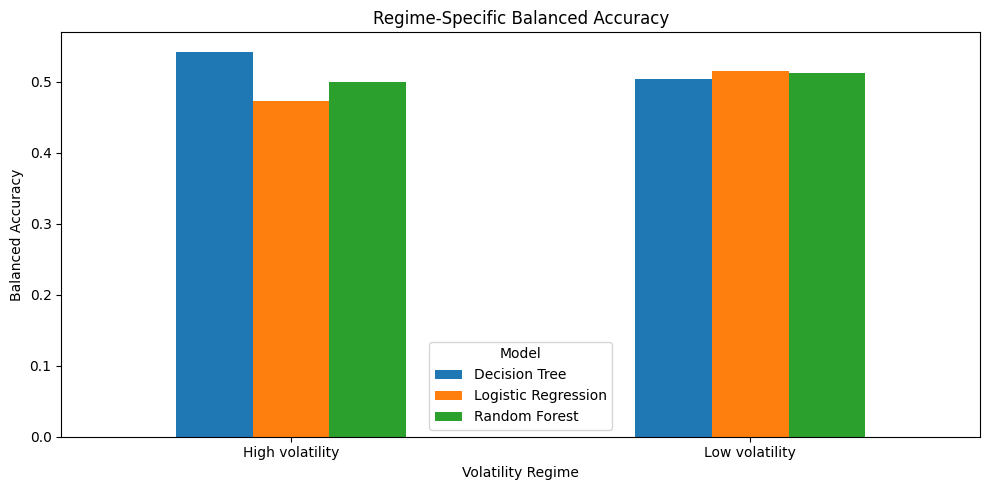

In [29]:
# Visualize balanced accuracy by regime.
if not regime_performance.empty:
    pivot_regime = regime_performance.pivot(index='regime', columns='model', values='balanced_accuracy')
    pivot_regime.plot(kind='bar', figsize=(10, 5))
    plt.title('Regime-Specific Balanced Accuracy')
    plt.ylabel('Balanced Accuracy')
    plt.xlabel('Volatility Regime')
    plt.xticks(rotation=0)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough observations for regime-specific plot.')

## **8. Rolling-Window Validation**

A single train-test split may overstate performance if the chosen period is favorable. Rolling-window validation repeatedly trains on one historical window and tests on the next window.

This is closer to a real decision environment, where a model must be periodically retrained and evaluated under changing conditions.

In [30]:
def rolling_window_validation(df, feature_cols, models, train_window=1500, test_window=300, step=300):
    rows = []
    n = len(df)
    fold = 0

    for start in range(0, n - train_window - test_window + 1, step):
        fold += 1
        train = df.iloc[start:start + train_window]
        test = df.iloc[start + train_window:start + train_window + test_window]

        X_train, y_train = train[feature_cols], train['target_direction']
        X_test, y_test = test[feature_cols], test['target_direction']

        base = evaluate_baselines(train, test)
        for _, r in base.iterrows():
            rows.append({
                'fold': fold,
                'model': r['model'],
                'accuracy': r['accuracy'],
                'balanced_accuracy': r['balanced_accuracy'],
                'f1': r['f1'],
                'roc_auc': r['roc_auc'],
                'test_start': test.index.min(),
                'test_end': test.index.max()
            })

        for name, model in models.items():
            clf = clone(model)
            clf.fit(X_train, y_train)
            pred = clf.predict(X_test)
            score = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else None
            m = classification_metrics(y_test, pred, score)
            rows.append({
                'fold': fold,
                'model': name,
                **m,
                'test_start': test.index.min(),
                'test_end': test.index.max()
            })

    return pd.DataFrame(rows)

n_obs = len(model_data)
train_window = min(1500, max(300, int(n_obs * 0.50)))
test_window = min(300, max(100, int(n_obs * 0.10)))
step = test_window

rolling_results = rolling_window_validation(
    model_data,
    feature_cols,
    models,
    train_window=train_window,
    test_window=test_window,
    step=step
)

rolling_summary = rolling_results.groupby('model').agg(
    folds=('fold', 'nunique'),
    mean_balanced_accuracy=('balanced_accuracy', 'mean'),
    std_balanced_accuracy=('balanced_accuracy', 'std'),
    mean_f1=('f1', 'mean'),
    mean_roc_auc=('roc_auc', 'mean')
).reset_index().sort_values('mean_balanced_accuracy', ascending=False)

rolling_summary

,model,folds,mean_balanced_accuracy,std_balanced_accuracy,mean_f1,mean_roc_auc
3,Random Forest,228,0.508103,0.025440,0.442172,0.517382
1,Logistic Regression,228,0.506543,0.023938,0.445142,0.513236
0,Decision Tree,228,0.505586,0.027351,0.437715,0.506776
2,Majority class,228,0.500000,0.000000,0.017157,NaN
4,Random-walk persistence,228,0.484663,0.029489,0.453534,NaN


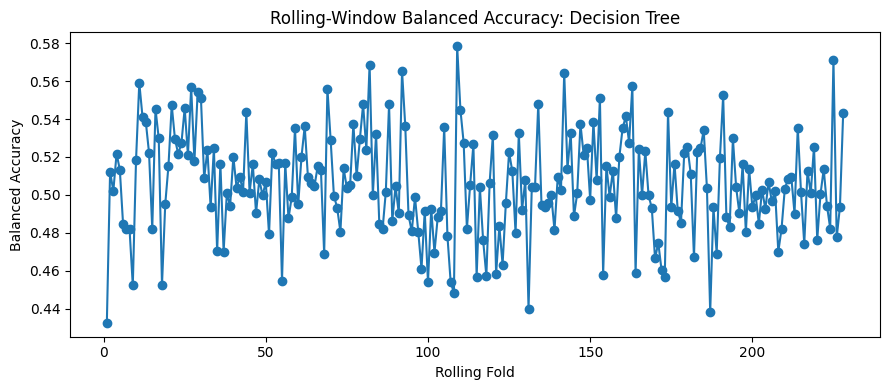

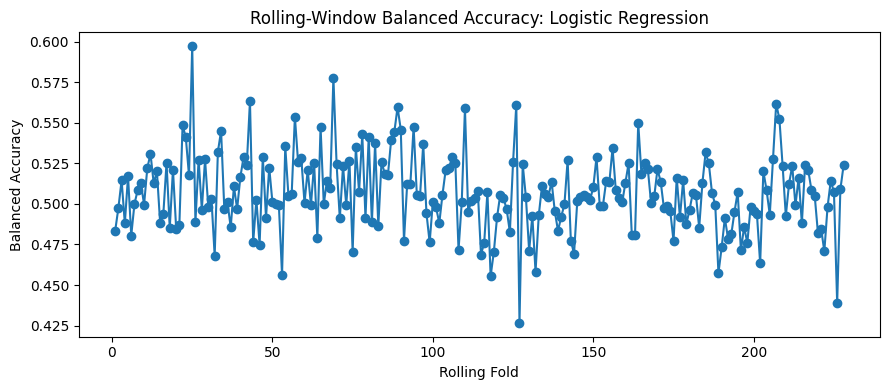

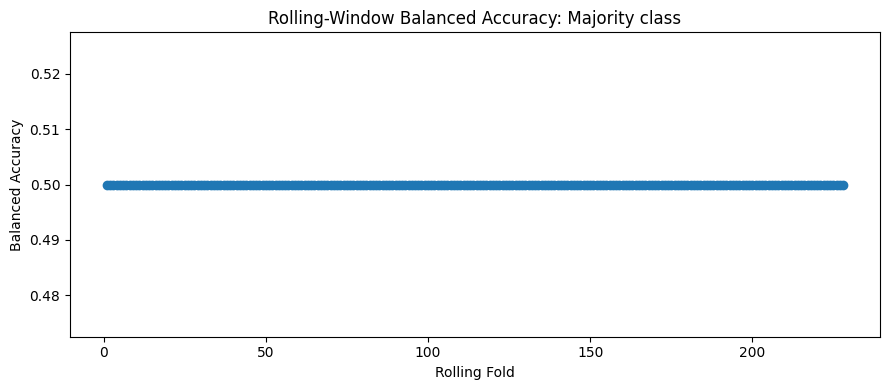

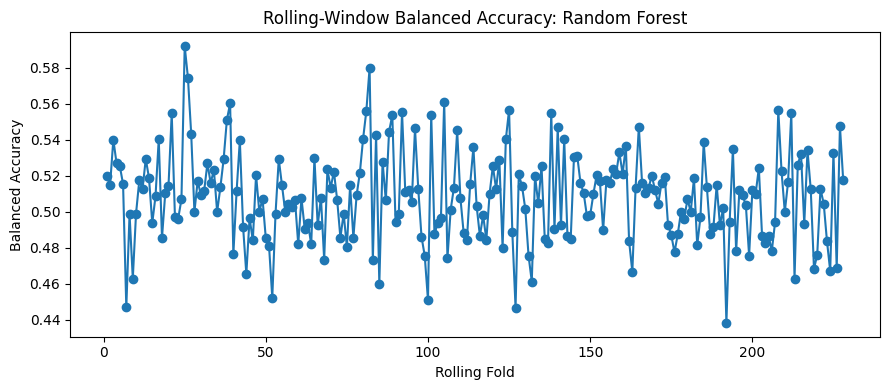

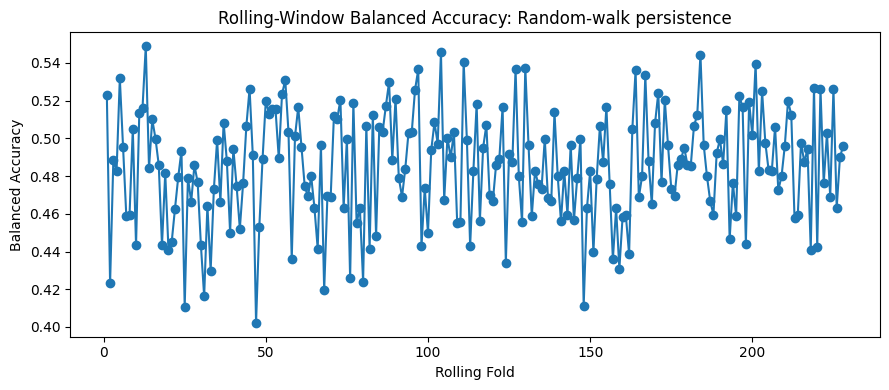

In [31]:
if not rolling_results.empty:
    for model_name, subset in rolling_results.groupby('model'):
        plt.figure(figsize=(9, 4))
        plt.plot(subset['fold'], subset['balanced_accuracy'], marker='o')
        plt.title(f'Rolling-Window Balanced Accuracy: {model_name}')
        plt.xlabel('Rolling Fold')
        plt.ylabel('Balanced Accuracy')
        plt.tight_layout()
        plt.show()

## **9. Interpretation for Research and PhD Applications**

This upgraded project should be presented as a study of **model reliability under uncertainty**, not as a trading strategy. The key contribution is the experimental design:

- Market uncertainty is operationalized through rolling and LSTM-based volatility proxies.
- Regimes are constructed from uncertainty signals.
- Models are evaluated both in aggregate and within each regime.
- Overfitting is explicitly measured using train-test performance gaps.
- Random-walk and naive benchmarks provide a minimum standard for predictive value.
- Rolling-window validation tests whether model performance is stable over time.

### PhD-oriented takeaway

A strong research interpretation would be:

> Machine learning models may show moderate aggregate predictive performance, but their usefulness for decision-making depends on whether that performance remains stable across volatility regimes and over time. This project therefore evaluates not only prediction accuracy, but also robustness, regime sensitivity, and uncertainty-aware decision quality.

### How to position this for Operations Management PhD applications

This project connects to OM research through:

- **Forecasting under non-stationarity**
- **Decision-making under uncertainty**
- **Robustness of data-driven decisions**
- **Predictive analytics for operational planning**
- **Model reliability across changing environments**

The finance setting becomes the empirical context, while the research logic is broader and transferable to operations settings such as demand forecasting, staffing, capacity planning, and service-system risk management.

## **Resume / CV Version**

**Regime-Dependent Predictive Modeling under Market Uncertainty**

- Led an applied machine learning research project on financial market prediction, focusing on how predictive accuracy and model reliability vary across different market regimes.
- Designed an experimental framework comparing logistic regression, decision trees, random forests, Gaussian mixture regime classification, LSTM-based volatility proxies, and random-walk benchmarks.
- Evaluated model robustness using regime-specific performance comparison, overfitting diagnostics, and rolling-window validation rather than relying on a single static train-test split.
- Investigated how volatility, temporal structure, feature selection, and regime changes influence out-of-sample prediction stability.
- Framed results from a decision-making perspective, emphasizing uncertainty, robustness, and model reliability rather than purely maximizing trading accuracy.